# 02 — ResNet: Residual Connections & Deep Networks
**Phase 3 · Week 10 · Tuesday · Jun 9 2026 · Campus**

## What We Cover Today
| Topic | Core Idea |
|---|---|
| Vanishing Gradient | Why very deep networks stop learning |
| Residual Connection | y = F(x) + x — shortcut that fixes the gradient problem |
| BasicBlock | 2 × (3×3 Conv → BN → ReLU) + shortcut |
| Bottleneck Block | 1×1 → 3×3 → 1×1 Conv — fewer params for deep variants |
| ResNet Variants | ResNet-18/34 use BasicBlock; ResNet-50/101/152 use Bottleneck |
| Identity vs Projection | When x and F(x) have different channels, project x with 1×1 conv |

---

## 1 · The Vanishing Gradient Problem

As networks get deeper, gradients shrink exponentially as they propagate backwards:

```
∂L/∂W₁ = ∂L/∂Wₙ · ∏ᵢ Wᵢ · σ'(Zᵢ)
```

For Sigmoid/Tanh: σ'(z) ≤ 0.25 always. With 50 layers: 0.25^50 ≈ 10^{-30} — effectively zero.

Even with ReLU (gradient = 0 or 1): dead neurons where gradient = 0 can block entire paths.

**Observation by He et al. (2015):** A 56-layer plain network performed WORSE than a 20-layer network on CIFAR-10. More depth was hurting, not helping.

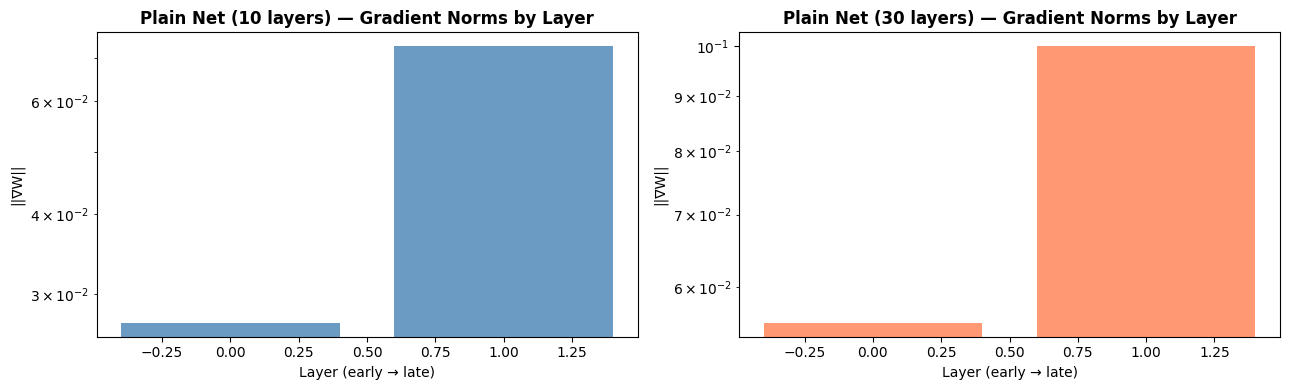

Notice: early layers (left) have near-zero gradients in the 30-layer net
This is the vanishing gradient problem — deeper layers stop learning.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Demonstrate vanishing gradient in a plain deep network ────────────────
class PlainDeepNet(nn.Module):
    def __init__(self, n_layers=20, width=64):
        super().__init__()
        layers = [nn.Linear(width, width), nn.ReLU()] * n_layers
        layers.append(nn.Linear(width, 10))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def measure_grad_norms(model, x, y):
    crit = nn.CrossEntropyLoss()
    out  = model(x)
    loss = crit(out, y)
    loss.backward()
    norms = []
    for name, p in model.named_parameters():
        if p.grad is not None and 'weight' in name:
            norms.append(p.grad.norm().item())
    return norms

x_dummy = torch.randn(32, 64)
y_dummy = torch.randint(0, 10, (32,))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, depth, color in zip(axes, [10, 30], ['steelblue', 'coral']):
    model = PlainDeepNet(n_layers=depth)
    norms = measure_grad_norms(model, x_dummy, y_dummy)
    ax.bar(range(len(norms)), norms, color=color, alpha=0.8)
    ax.set_title(f"Plain Net ({depth} layers) — Gradient Norms by Layer",
                 fontweight='bold')
    ax.set_xlabel("Layer (early → late)"); ax.set_ylabel("||∇W||")
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig("vanishing_gradient.png", dpi=120, bbox_inches='tight')
plt.show()
print("Notice: early layers (left) have near-zero gradients in the 30-layer net")
print("This is the vanishing gradient problem — deeper layers stop learning.")

---

## 2 · The Residual Connection — The Fix

He et al. added a **shortcut** that bypasses one or more layers:

```
Plain block:       y = F(x, {Wᵢ})           where F = conv→BN→ReLU→conv→BN

Residual block:    y = F(x, {Wᵢ}) + x        ← add the input back!
                   y = ReLU(y)
```

**Why does this help?**

1. **Gradient highway** — gradient flows directly through the shortcut without touching any weights: `∂L/∂x = ∂L/∂y · (∂F/∂x + 1)`. The `+1` ensures gradient never vanishes completely.

2. **Easy identity** — if F(x)≈0 is optimal, the block easily learns zero weights and just passes x through. Without the shortcut the block would have to learn a precise identity mapping.

3. **Ensemble effect** — a ResNet of depth L can be viewed as an ensemble of 2^L shallow networks of different depths (each path through the shortcuts is a separate network).

In [2]:
class BasicBlock(nn.Module):
    """ResNet BasicBlock: used in ResNet-18 and ResNet-34"""
    expansion = 1

    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)

        # Projection shortcut: when stride>1 or channels change, x dims don't match F(x)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)      # ← THE residual connection
        return self.relu(out)


class BottleneckBlock(nn.Module):
    """ResNet Bottleneck: used in ResNet-50/101/152 — reduces params with 1×1 convs"""
    expansion = 4

    def __init__(self, in_ch, mid_ch, stride=1):
        super().__init__()
        out_ch = mid_ch * self.expansion
        self.conv1 = nn.Conv2d(in_ch,  mid_ch, 1, bias=False); self.bn1 = nn.BatchNorm2d(mid_ch)
        self.conv2 = nn.Conv2d(mid_ch, mid_ch, 3, stride=stride, padding=1, bias=False); self.bn2 = nn.BatchNorm2d(mid_ch)
        self.conv3 = nn.Conv2d(mid_ch, out_ch, 1, bias=False); self.bn3 = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out = out + self.shortcut(x)
        return self.relu(out)

# Verify shapes
x = torch.randn(4, 64, 14, 14)
bb = BasicBlock(64, 64, stride=1)
bb_down = BasicBlock(64, 128, stride=2)
print(f"BasicBlock (same channels, stride=1)  : {x.shape} → {bb(x).shape}")
print(f"BasicBlock (double channels, stride=2) : {x.shape} → {bb_down(x).shape}")

x2 = torch.randn(4, 64, 56, 56)
btl = BottleneckBlock(64, 64)
print(f"BottleneckBlock (64→256, same spatial) : {x2.shape} → {btl(x2).shape}")

BasicBlock (same channels, stride=1)  : torch.Size([4, 64, 14, 14]) → torch.Size([4, 64, 14, 14])
BasicBlock (double channels, stride=2) : torch.Size([4, 64, 14, 14]) → torch.Size([4, 128, 7, 7])
BottleneckBlock (64→256, same spatial) : torch.Size([4, 64, 56, 56]) → torch.Size([4, 256, 56, 56])


---

## 3 · ResNet-18 — Full Architecture

ResNet-18 uses BasicBlocks. Architecture:

```
Input (3×H×W)
  ↓  Conv(64, 7×7, stride=2) → BN → ReLU → MaxPool(3×3, stride=2)   [stem]
  ↓  Layer1: 2 × BasicBlock(64,  64,  stride=1)
  ↓  Layer2: 2 × BasicBlock(64,  128, stride=2)    ← first block downsamples
  ↓  Layer3: 2 × BasicBlock(128, 256, stride=2)
  ↓  Layer4: 2 × BasicBlock(256, 512, stride=2)
  ↓  Global Average Pool → FC(512, num_classes)
```

Total: 18 weight layers (hence ResNet-18). ~11M parameters.

In [3]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),  # CIFAR: 3×3 stem
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        # Residual layers
        self.layer1 = self._make_layer(64,  64,  n_blocks=2, stride=1)
        self.layer2 = self._make_layer(64,  128, n_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, n_blocks=2, stride=2)
        # Head (3 layer groups instead of 4 — faster on CPU)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Linear(256, num_classes)

        # He initialisation
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, in_ch, out_ch, n_blocks, stride):
        layers = [BasicBlock(in_ch, out_ch, stride=stride)]
        for _ in range(1, n_blocks):
            layers.append(BasicBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x)
        return self.fc(self.gap(x).flatten(1))

resnet18 = ResNet18(num_classes=10)
total = sum(p.numel() for p in resnet18.parameters())

# Shape trace
x = torch.randn(2, 3, 32, 32)
print("ResNet-18 shape trace (CIFAR 32×32 input):")
x = resnet18.stem(x);   print(f"  stem    : {x.shape}")
x = resnet18.layer1(x); print(f"  layer1  : {x.shape}")
x = resnet18.layer2(x); print(f"  layer2  : {x.shape}")
x = resnet18.layer3(x); print(f"  layer3  : {x.shape}")
x = resnet18.gap(x).flatten(1); print(f"  GAP+flat: {x.shape}")
print(f"\nTotal parameters: {total:,}")

ResNet-18 shape trace (CIFAR 32×32 input):


  stem    : torch.Size([2, 64, 32, 32])
  layer1  : torch.Size([2, 64, 32, 32])
  layer2  : torch.Size([2, 128, 16, 16])
  layer3  : torch.Size([2, 256, 8, 8])
  GAP+flat: torch.Size([2, 256])

Total parameters: 2,777,674


TinyResNet   params: 175,258
TinyPlainNet params: 172,506
Training ResNet vs PlainNet (10 epochs, 1200 samples)...


ResNet   final val acc: 0.250
PlainNet final val acc: 0.320


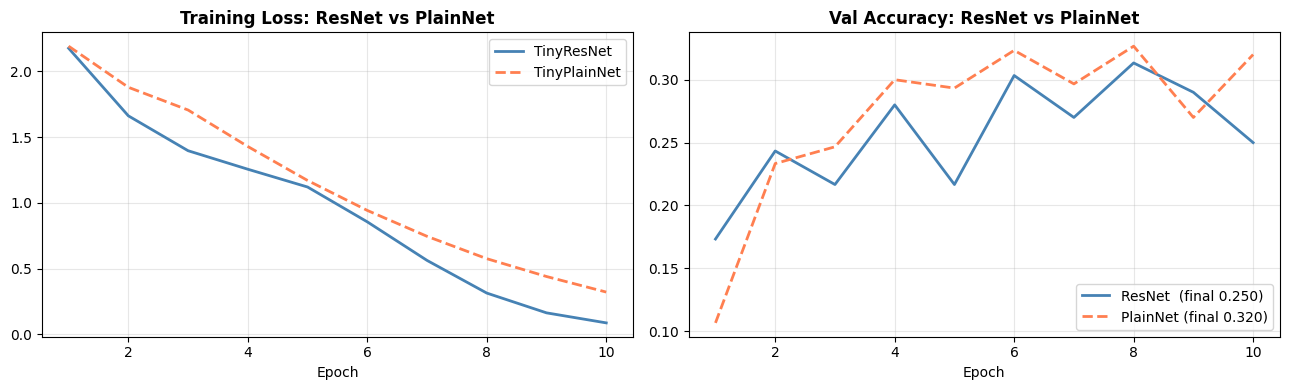

In [4]:
# ── Tiny ResNet vs PlainNet comparison (fast CPU demo) ──────────────────────
# Small channels [16,32,64] so training finishes in <60s on CPU

class TinyResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem   = nn.Sequential(nn.Conv2d(3,16,3,padding=1,bias=False), nn.BatchNorm2d(16), nn.ReLU())
        self.layer1 = nn.Sequential(BasicBlock(16,16,1), BasicBlock(16,16,1))
        self.layer2 = nn.Sequential(BasicBlock(16,32,2), BasicBlock(32,32,1))
        self.layer3 = nn.Sequential(BasicBlock(32,64,2), BasicBlock(64,64,1))
        self.head   = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(64, num_classes))
        for m in self.modules():
            if isinstance(m, nn.Conv2d): nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d): nn.init.constant_(m.weight,1); nn.init.constant_(m.bias,0)
    def forward(self, x):
        return self.head(self.layer3(self.layer2(self.layer1(self.stem(x)))))

class TinyPlainNet(nn.Module):
    # Same depth but NO skip connections
    def __init__(self, num_classes=10):
        super().__init__()
        def blk(ic,oc,s): return nn.Sequential(
            nn.Conv2d(ic,oc,3,stride=s,padding=1,bias=False), nn.BatchNorm2d(oc), nn.ReLU(),
            nn.Conv2d(oc,oc,3,padding=1,bias=False), nn.BatchNorm2d(oc), nn.ReLU())
        self.net = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1,bias=False), nn.BatchNorm2d(16), nn.ReLU(),
            blk(16,16,1), blk(16,16,1), blk(16,32,2), blk(32,32,1), blk(32,64,2), blk(64,64,1),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(64, num_classes))
    def forward(self, x): return self.net(x)

def quick_train(model, n=1200, epochs=10, lr=1e-3):
    X = torch.randn(n, 3, 32, 32)
    y = torch.randint(0, 10, (n,))
    for cls in range(10): X[y==cls, cls%3, :6, :6] += 2.0
    Xv = torch.randn(300, 3, 32, 32)
    yv = torch.randint(0, 10, (300,))
    for cls in range(10): Xv[yv==cls, cls%3, :6, :6] += 2.0
    loader = DataLoader(TensorDataset(X, y), batch_size=64, shuffle=True)
    opt    = optim.Adam(model.parameters(), lr=lr)
    crit   = nn.CrossEntropyLoss()
    model  = model.to(device)
    losses, accs = [], []
    for ep in range(epochs):
        model.train(); ep_l = []
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(Xb), yb)
            loss.backward(); opt.step(); ep_l.append(loss.item())
        losses.append(np.mean(ep_l))
        model.eval()
        with torch.no_grad():
            acc = (model(Xv.to(device)).argmax(1).cpu() == yv).float().mean().item()
        accs.append(acc)
    return losses, accs

r_p = sum(p.numel() for p in TinyResNet().parameters())
n_p = sum(p.numel() for p in TinyPlainNet().parameters())
print(f"TinyResNet   params: {r_p:,}")
print(f"TinyPlainNet params: {n_p:,}")
print("Training ResNet vs PlainNet (10 epochs, 1200 samples)...")

res_losses,   res_accs   = quick_train(TinyResNet(),   n=1200, epochs=10)
plain_losses, plain_accs = quick_train(TinyPlainNet(), n=1200, epochs=10)

print(f"ResNet   final val acc: {res_accs[-1]:.3f}")
print(f"PlainNet final val acc: {plain_accs[-1]:.3f}")

ep_ax = range(1, 11)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(ep_ax, res_losses,   'steelblue', lw=2, label='TinyResNet')
ax1.plot(ep_ax, plain_losses, 'coral',     lw=2, label='TinyPlainNet', ls='--')
ax1.set_title("Training Loss: ResNet vs PlainNet", fontweight='bold')
ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep_ax, res_accs,   'steelblue', lw=2, label=f"ResNet  (final {res_accs[-1]:.3f})")
ax2.plot(ep_ax, plain_accs, 'coral',     lw=2, label=f"PlainNet (final {plain_accs[-1]:.3f})", ls='--')
ax2.set_title("Val Accuracy: ResNet vs PlainNet", fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("resnet_vs_plain.png", dpi=120, bbox_inches='tight')
plt.show()


---

## What I Learned Today

**Vanishing gradient** — In deep networks, gradients multiply through every layer during backprop. Small multipliers (< 1) shrink them exponentially. A 30-layer plain net can have near-zero gradients in early layers — those weights never update.

**Residual connection: y = F(x) + x** — The shortcut adds the input directly to the output of the conv block. During backprop, gradient flows through the shortcut unchanged (derivative of x w.r.t. x = 1), creating a "gradient highway." This is the single most impactful idea in modern CNN design.

**BasicBlock** — 2 × (Conv3×3 → BN → ReLU) + shortcut. Projection shortcut (1×1 Conv) used when dimensions change (stride>1 or channel change).

**Bottleneck** — 1×1 Conv (reduce channels) → 3×3 Conv → 1×1 Conv (restore channels). Used in ResNet-50/101/152. The 1×1 convs reduce computation while the 3×3 does the main feature extraction.

**ResNet variants:**
```
ResNet-18:  BasicBlock × [2,2,2,2] — ~11M params
ResNet-34:  BasicBlock × [3,4,6,3] — ~21M params
ResNet-50:  Bottleneck × [3,4,6,3] — ~25M params
ResNet-101: Bottleneck × [3,4,23,3] — ~44M params
```

**He initialisation** — Critical for ResNets. `kaiming_normal_` with `fan_out` mode sets weights so gradient variance is stable at initialisation: scale = √(2 / fan_out).